# CNN-LSTM Predictive Maintenance — Overlock Sewing Machine
### Training Notebook — Model 1 (Classifier) + Model 2 (Autoencoder)

#### Cell 1 — Imports & Environment Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, BatchNormalization, RepeatVector,
    TimeDistributed, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('✅ Imports complete.')

✅ Imports complete.


#### Cell 2 — Configuration
> Update file paths and settings here. Everything else scales automatically.

In [2]:
# ── FILE PATHS ──────────────────────────────────────────────────────
# All files must be in the same folder as this notebook
HEALTHY_DATA_FILE    = r'C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\Datasets\MBP ControllerData 0521760 Overlock.xlsx'
SYNTHETIC_DATA_FILE  = r'C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\Datasets\Synthetic_Breakdown_Dataset_Final.xlsx'
REAL_BREAKDOWN_FILE  = r'C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\Datasets\Real Breakdown Records - Overlock.xlsx'

# ── MODEL SETTINGS ──────────────────────────────────────────────────
TIME_STEPS = 7          # Consecutive records LSTM looks across
EPOCHS     = 100        # Max training epochs (early stopping applies)
BATCH_SIZE = 32

# ── KNOWN BREAKDOWN CLASSES ─────────────────────────────────────────
# Add new breakdown names here as real data is collected
# Labels must exactly match the Breakdown column in your data files
KNOWN_BREAKDOWNS = [
    'Waveness',
    'High Foot Pressure',
    'Skip Stitches/Slip',
    'Blade Blunt',
    # 'Needle Breakages',      # Uncomment when real data is available
    # 'Thread Breakages',
    # 'Cut/Needle Hole',
    # 'Pneumatic Issues',
    # 'Thread Jamming',
    # 'Code Uneven',
    # 'Roping',
    # 'Oil Mark',
    # 'Gathering/Puckering',
    # 'Binding/Seam Open',
]

ALLOWED_STATES = ['Healthy'] + KNOWN_BREAKDOWNS

print(f'✅ Config loaded.')
print(f'   TIME_STEPS      : {TIME_STEPS}')
print(f'   Known breakdowns: {len(KNOWN_BREAKDOWNS)}')
print(f'   Total classes   : {len(ALLOWED_STATES)}')

✅ Config loaded.
   TIME_STEPS      : 7
   Known breakdowns: 4
   Total classes   : 5


#### Cell 3 — Data Loading & Merging

In [3]:
# Load healthy data
df_healthy = pd.read_excel(HEALTHY_DATA_FILE)
df_healthy = df_healthy[df_healthy['machineVibration'].astype(str).str.startswith('10')]
df_healthy['Breakdown'] = df_healthy['Breakdown'].fillna('Healthy')
df_healthy = df_healthy[df_healthy['Breakdown'] == 'Healthy'].copy()

# Load synthetic breakdown data
df_synthetic = pd.read_excel(SYNTHETIC_DATA_FILE)
df_synthetic = df_synthetic[df_synthetic['machineVibration'].astype(str).str.startswith('10')]

# Load real breakdown data
df_real_bd = pd.read_excel(REAL_BREAKDOWN_FILE)
df_real_bd = df_real_bd[df_real_bd['machineVibration'].astype(str).str.startswith('10')]

# Combine all breakdown data
df_breakdown = pd.concat([df_synthetic, df_real_bd], ignore_index=True)
df_breakdown = df_breakdown[df_breakdown['Breakdown'].isin(KNOWN_BREAKDOWNS)].copy()

# Combine healthy + breakdown into master dataset
master_df = pd.concat([df_healthy, df_breakdown], ignore_index=True)
master_df  = master_df[master_df['Breakdown'].isin(ALLOWED_STATES)].copy()

print('✅ Data loaded and merged.')
print(f'   Healthy records : {len(df_healthy)}')
print(f'   Synthetic BD    : {len(df_synthetic)}')
print(f'   Real BD         : {len(df_real_bd)}')
print(f'   Master total    : {len(master_df)}')
print(f'\nClass distribution:')
print(master_df['Breakdown'].value_counts())

✅ Data loaded and merged.
   Healthy records : 4947
   Synthetic BD    : 420
   Real BD         : 7
   Master total    : 5374

Class distribution:
Breakdown
Healthy               4947
High Foot Pressure     109
Waveness               106
Skip Stitches/Slip     106
Blade Blunt            106
Name: count, dtype: int64


#### Cell 4 — Feature Extraction
> Parses vibration string into 60 frequency band columns + 6 electrical features = 66 features total

In [4]:
def extract_features(df):
    """
    Extracts 66 features from each record:
      - 60 vibration frequency band amplitudes (10-20Hz to 600-610Hz)
      - 6 electrical features: voltage mean/min/max, current mean/min/max
    Power is excluded — it is derived from voltage x current
    and would introduce redundancy.
    """
    vib_records = []
    for val in df['machineVibration']:
        vib_dict = {}
        parts = str(val).split(',')
        try:
            for i in range(0, len(parts) - 1, 2):
                f_start = int(parts[i])
                vib_dict[f'{f_start}-{f_start+10}Hz'] = int(parts[i+1])
        except:
            pass
        vib_records.append(vib_dict)

    # Enforce exactly 60 vibration columns — fill missing with 0
    expected_vib_cols = [f'{i}-{i+10}Hz' for i in range(10, 610, 10)]
    vib_df = pd.DataFrame(vib_records).reindex(columns=expected_vib_cols, fill_value=0)

    # 6 electrical features
    elec_df = df[[
        'machineVoltageMean', 'machineVoltageMin', 'machineVoltageMax',
        'machineCurrentMean', 'machineCurrentMin', 'machineCurrentMax'
    ]].ffill().fillna(0).reset_index(drop=True)

    features = pd.concat([vib_df, elec_df], axis=1)
    return features

X_all = extract_features(master_df)
y_all = master_df['Breakdown'].values

print(f'✅ Features extracted.')
print(f'   Feature shape   : {X_all.shape}')
print(f'   Vibration cols  : 60')
print(f'   Electrical cols : 6')
print(f'   Total features  : {X_all.shape[1]}')

✅ Features extracted.
   Feature shape   : (5374, 66)
   Vibration cols  : 60
   Electrical cols : 6
   Total features  : 66


#### Cell 5 — Label Encoding & Train/Test Split

In [9]:
# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_all)
num_classes = len(encoder.classes_)

print(f'✅ Classes encoded: {list(encoder.classes_)}')

# Stratified split — preserves class distribution in both sets
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_all.values, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'   Train samples   : {len(X_train_raw)}')
print(f'   Test samples    : {len(X_test_raw)}')

✅ Classes encoded: ['Blade Blunt', 'Healthy', 'High Foot Pressure', 'Skip Stitches/Slip', 'Waveness']
   Train samples   : 4299
   Test samples    : 1075


#### Cell 6 — Feature Scaling (Leakage-Free)

In [10]:
# Fit scaler ONLY on training data — prevents data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print('✅ Scaler fitted on training data only (no leakage).')

✅ Scaler fitted on training data only (no leakage).


#### Cell 7 — Sequence Creation (7-Step Sliding Window)
> Each sequence contains TIME_STEPS=7 consecutive records.
> CNN processes each record individually.
> LSTM reads the degradation progression across the 7 records.

In [11]:
def create_sequences(X, y, time_steps):
    """
    Builds sliding windows of TIME_STEPS consecutive records.
    Each window captures the degradation progression the LSTM
    needs to detect approaching breakdowns.
    Output shape: (samples, time_steps, features)
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i : i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_raw, TIME_STEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_raw,  TIME_STEPS)

# One-hot encode for classifier
y_train_cat = to_categorical(y_train_seq, num_classes=num_classes)
y_test_cat  = to_categorical(y_test_seq,  num_classes=num_classes)

print(f'✅ Sequences created.')
print(f'   Train shape : {X_train_seq.shape}  →  (samples, {TIME_STEPS} records, 66 features)')
print(f'   Test shape  : {X_test_seq.shape}')

✅ Sequences created.
   Train shape : (4292, 7, 66)  →  (samples, 7 records, 66 features)
   Test shape  : (1068, 7, 66)


---
## Model 1 — CNN-LSTM Classifier
> CNN extracts spectral patterns within each record.
> LSTM learns degradation progression across 7 consecutive records.
> Output: 5-class softmax (Healthy + 4 known breakdowns).

#### Cell 8 — CNN-LSTM Classifier Architecture

In [15]:
num_features = X_train_seq.shape[2]  # 66

inputs = Input(shape=(TIME_STEPS, num_features, 1))

# ── CNN BLOCK ───────────────────────────────────────────────────────
# TimeDistributed applies the same CNN to each of the 7 records
# independently — extracting spectral patterns per record
x = TimeDistributed(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))(inputs)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling1D(pool_size=2))(x)
x = TimeDistributed(Dropout(0.2))(x)
x = TimeDistributed(Flatten())(x)

# ── LSTM BLOCK ──────────────────────────────────────────────────────
# LSTM reads the sequence of CNN feature vectors across 7 records
# learning how spectral patterns evolve toward a breakdown
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# ── CLASSIFICATION HEAD ─────────────────────────────────────────────
x = Dense(32, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

classifier = Model(inputs, outputs, name='CNN_LSTM_Classifier')
classifier.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
classifier.summary()

Model: "CNN_LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 7, 66, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 7, 66, 64)      │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 7, 66, 64)      │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 7, 66, 32)      │         6,176 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 7, 66, 32)      │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 7, 33, 32)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 7, 33, 32)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 7, 1056)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 64)          │       286,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,429 (1.17 MB)

 Trainable params: 307,237 (1.17 MB)

 Non-trainable params: 192 (768.00 B)

#### Cell 9 — Train Classifier

Training CNN-LSTM Classifier...
Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.9080 - loss: 0.4687 - val_accuracy: 0.9204 - val_loss: 0.3946
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.9205 - loss: 0.3949 - val_accuracy: 0.9204 - val_loss: 0.3972
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.9205 - loss: 0.3959 - val_accuracy: 0.9204 - val_loss: 0.3903
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9205 - loss: 0.3909 - val_accuracy: 0.9204 - val_loss: 0.3909
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.9205 - loss: 0.3893 - val_accuracy: 0.9204 - val_loss: 0.3908
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.9205 - loss: 0.3864 - val_accuracy: 0.9204 - val_loss: 0.3918
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9205 - loss: 0.3776 - val_accuracy: 0.9204 - val_loss: 0.4038
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/

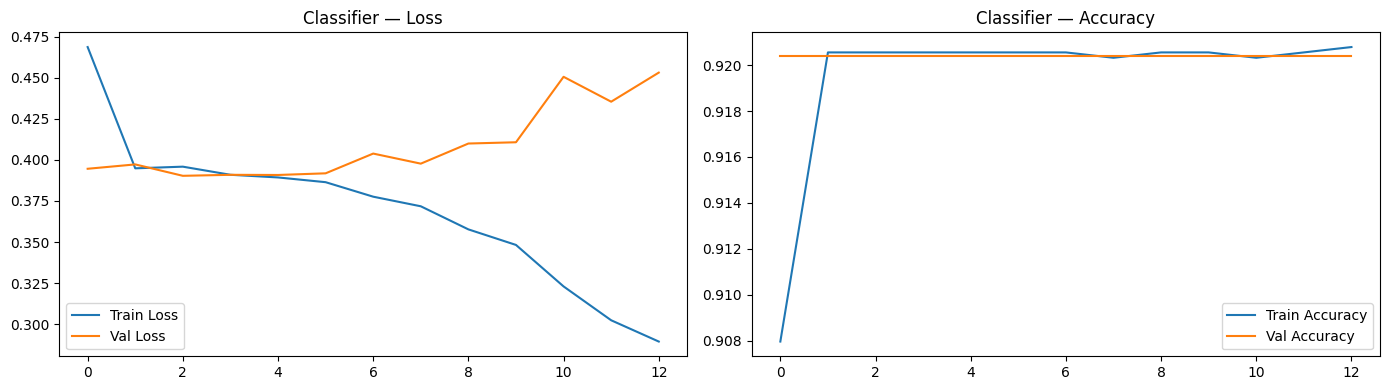

In [16]:
early_stop  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint  = ModelCheckpoint('best_classifier.keras', monitor='val_accuracy', save_best_only=True)

print('Training CNN-LSTM Classifier...')
history_cls = classifier.fit(
    X_train_seq, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_seq, y_test_cat),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_cls.history['loss'],     label='Train Loss')
axes[0].plot(history_cls.history['val_loss'], label='Val Loss')
axes[0].set_title('Classifier — Loss')
axes[0].legend()
axes[1].plot(history_cls.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_cls.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Classifier — Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('classifier_training_curves.png', dpi=150)
plt.show()

#### Cell 10 — Classifier Evaluation

Classifier Test Accuracy : 92.04%
Classifier Test Loss     : 0.3903

Classification Report:
                    precision    recall  f1-score   support

       Blade Blunt       0.00      0.00      0.00        21
           Healthy       0.92      1.00      0.96       983
High Foot Pressure       0.00      0.00      0.00        22
Skip Stitches/Slip       0.00      0.00      0.00        21
          Waveness       0.00      0.00      0.00        21

          accuracy                           0.92      1068
         macro avg       0.18      0.20      0.19      1068
      weighted avg       0.85      0.92      0.88      1068



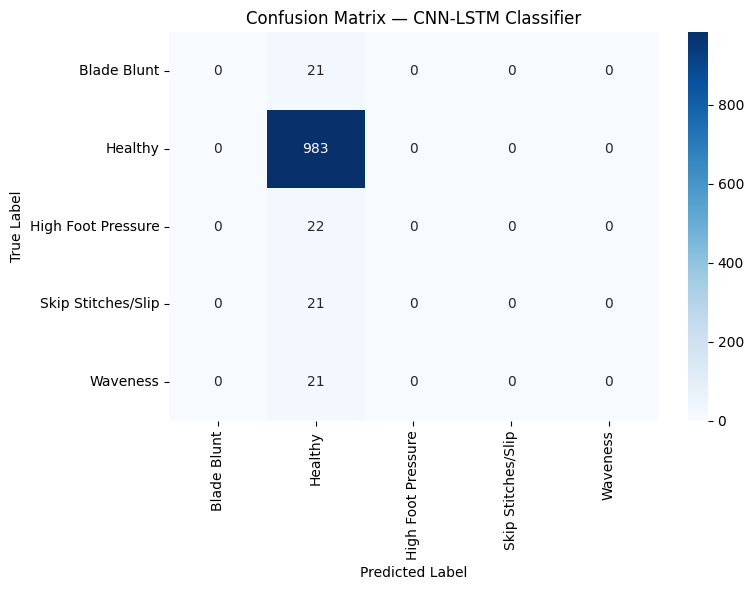

In [17]:
test_loss, test_acc = classifier.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f'Classifier Test Accuracy : {test_acc*100:.2f}%')
print(f'Classifier Test Loss     : {test_loss:.4f}')

# Per-class report
y_pred     = np.argmax(classifier.predict(X_test_seq, verbose=0), axis=1)
y_true     = y_test_seq
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix — CNN-LSTM Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('classifier_confusion_matrix.png', dpi=150)
plt.show()

---
## Model 2 — CNN-LSTM Autoencoder
> Trained ONLY on healthy data.
> Learns to reconstruct normal machine behaviour perfectly.
> High reconstruction error on incoming record = unknown anomaly detected.
> Handles State 4 (Approaching Unknown) and State 5 (Running With Unknown).

#### Cell 11 — Prepare Healthy-Only Sequences for Autoencoder

In [18]:
# Extract and scale healthy records only
healthy_only_df  = master_df[master_df['Breakdown'] == 'Healthy'].copy()
X_healthy        = extract_features(healthy_only_df)
X_healthy_scaled = scaler.transform(X_healthy.values)  # Use same scaler

# Create sequences from healthy data only
def create_sequences_unsupervised(X, time_steps):
    Xs = []
    for i in range(len(X) - time_steps):
        Xs.append(X[i : i + time_steps])
    return np.array(Xs)

X_healthy_seq = create_sequences_unsupervised(X_healthy_scaled, TIME_STEPS)

# 80/20 split for autoencoder
split = int(len(X_healthy_seq) * 0.8)
X_ae_train = X_healthy_seq[:split]
X_ae_test  = X_healthy_seq[split:]

print(f'✅ Healthy sequences prepared for Autoencoder.')
print(f'   Train shape : {X_ae_train.shape}')
print(f'   Test shape  : {X_ae_test.shape}')

✅ Healthy sequences prepared for Autoencoder.
   Train shape : (3952, 7, 66)
   Test shape  : (988, 7, 66)


#### Cell 12 — CNN-LSTM Autoencoder Architecture

In [20]:
ae_inputs = Input(shape=(TIME_STEPS, num_features, 1))

# ── ENCODER ─────────────────────────────────────────────────────────
# CNN extracts spectral features from each record
e = TimeDistributed(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'))(ae_inputs)
e = TimeDistributed(BatchNormalization())(e)
e = TimeDistributed(MaxPooling1D(pool_size=2))(e)
e = TimeDistributed(Flatten())(e)
# LSTM compresses the sequence into a fixed-length representation
e = LSTM(32, return_sequences=False)(e)
encoded = Dense(16, activation='relu', name='bottleneck')(e)

# ── DECODER ─────────────────────────────────────────────────────────
# Reconstruct the original sequence from the compressed representation
d = RepeatVector(TIME_STEPS)(encoded)
d = LSTM(32, return_sequences=True)(d)
decoded = TimeDistributed(Dense(num_features))(d)

autoencoder = Model(ae_inputs, decoded, name='CNN_LSTM_Autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "CNN_LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 7, 66, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 7, 66, 32)      │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 7, 66, 32)      │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 7, 33, 32)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 7, 1056)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │       139,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 7, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 7, 66)          │         2,178 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,626 (580.57 KB)

 Trainable params: 148,562 (580.32 KB)

 Non-trainable params: 64 (256.00 B)

#### Cell 13 — Train Autoencoder

Training CNN-LSTM Autoencoder on healthy data only...
Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.9194 - val_loss: 0.8497
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.8520 - val_loss: 0.8299
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.8335 - val_loss: 0.8154
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.8172 - val_loss: 0.8078
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.8006 - val_loss: 0.7953
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.7924 - val_loss: 0.7864
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.7847 - val_loss: 0.7808
Epoch 8/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.7764 - val_loss: 0.7723
Epoch 9/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.7663 - val_loss: 0.7616
Epoch 10/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.7521 - val_loss: 0.7494
Epoch 11/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0

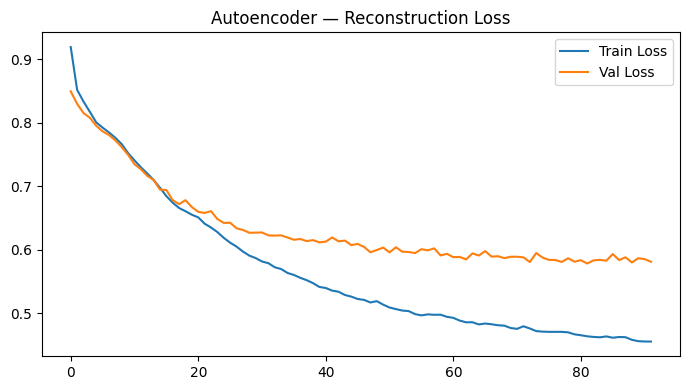

In [21]:
ae_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ae_checkpoint = ModelCheckpoint('best_autoencoder.keras', monitor='val_loss', save_best_only=True)

print('Training CNN-LSTM Autoencoder on healthy data only...')
history_ae = autoencoder.fit(
    X_ae_train, X_ae_train,   # Input = Target (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_ae_test, X_ae_test),
    callbacks=[ae_early_stop, ae_checkpoint],
    verbose=1
)

plt.figure(figsize=(7, 4))
plt.plot(history_ae.history['loss'],     label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Val Loss')
plt.title('Autoencoder — Reconstruction Loss')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_training_curve.png', dpi=150)
plt.show()

#### Cell 14 — Reconstruction Error Analysis
> Use this to manually tune the anomaly detection threshold.

Reconstruction Error on Healthy Data:
  Mean   : 0.487457
  Std    : 0.165824
  Max    : 1.299755
  p95    : 0.819111
  p99    : 1.045780

── THRESHOLD GUIDANCE ──────────────────────────────────────
  Suggested warning threshold  (p95) : 0.819111
  Suggested critical threshold (p99) : 1.045780
  Tune ANOMALY_THRESHOLD in Live_Analyser.ipynb based on these values.


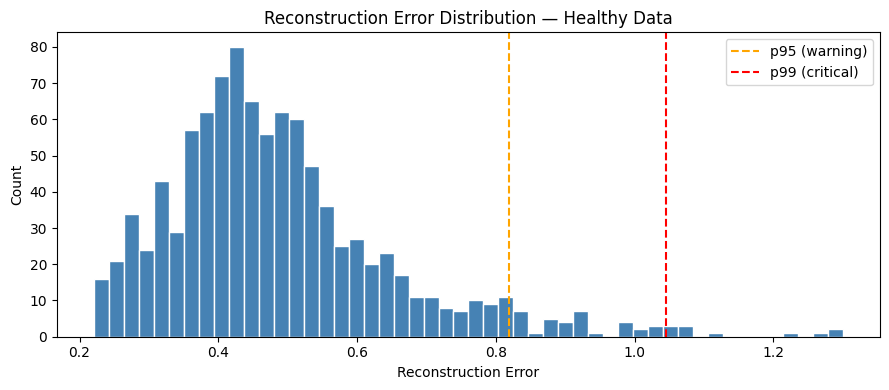


Save these values in Live_Analyser.ipynb:
  ANOMALY_WARNING_THRESHOLD  = 0.819111
  ANOMALY_CRITICAL_THRESHOLD = 1.045780


In [22]:
# Reconstruction errors on healthy test set
X_ae_pred  = autoencoder.predict(X_ae_test, verbose=0)
recon_errors = np.mean(np.abs(X_ae_test - X_ae_pred), axis=(1, 2))

print('Reconstruction Error on Healthy Data:')
print(f'  Mean   : {np.mean(recon_errors):.6f}')
print(f'  Std    : {np.std(recon_errors):.6f}')
print(f'  Max    : {np.max(recon_errors):.6f}')
print(f'  p95    : {np.percentile(recon_errors, 95):.6f}')
print(f'  p99    : {np.percentile(recon_errors, 99):.6f}')
print()
print('── THRESHOLD GUIDANCE ──────────────────────────────────────')
print(f'  Suggested warning threshold  (p95) : {np.percentile(recon_errors, 95):.6f}')
print(f'  Suggested critical threshold (p99) : {np.percentile(recon_errors, 99):.6f}')
print('  Tune ANOMALY_THRESHOLD in Live_Analyser.ipynb based on these values.')

# Plot error distribution
plt.figure(figsize=(9, 4))
plt.hist(recon_errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(recon_errors, 95), color='orange', linestyle='--', label='p95 (warning)')
plt.axvline(np.percentile(recon_errors, 99), color='red',    linestyle='--', label='p99 (critical)')
plt.title('Reconstruction Error Distribution — Healthy Data')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_error_distribution.png', dpi=150)
plt.show()

# Save threshold values for reference
threshold_p95 = float(np.percentile(recon_errors, 95))
threshold_p99 = float(np.percentile(recon_errors, 99))
print(f'\nSave these values in Live_Analyser.ipynb:')
print(f'  ANOMALY_WARNING_THRESHOLD  = {threshold_p95:.6f}')
print(f'  ANOMALY_CRITICAL_THRESHOLD = {threshold_p99:.6f}')

#### Cell 15 — Export All Artifacts

In [23]:
# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoder
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

# Save threshold values
thresholds = {
    'warning_threshold' : threshold_p95,
    'critical_threshold': threshold_p99
}
with open('ae_thresholds.pkl', 'wb') as f:
    pickle.dump(thresholds, f)

print('✅ All artifacts exported:')
print('   best_classifier.keras')
print('   best_autoencoder.keras')
print('   scaler.pkl')
print('   encoder.pkl')
print('   ae_thresholds.pkl')
print()
print(f'Final Classifier Accuracy : {test_acc*100:.2f}%')
print(f'Classes                   : {list(encoder.classes_)}')

✅ All artifacts exported:
   best_classifier.keras
   best_autoencoder.keras
   scaler.pkl
   encoder.pkl
   ae_thresholds.pkl

Final Classifier Accuracy : 92.04%
Classes                   : ['Blade Blunt', 'Healthy', 'High Foot Pressure', 'Skip Stitches/Slip', 'Waveness']
